## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

In [1]:
# General imports
import sys
import os

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 
from torch_geometric.nn import GATv2Conv


# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer # Training script handles dataloaders 
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


## Define Model

### Input: Simple Graphs Only

In [3]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_simple(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)
        # Implement weight decay to limit overfitting
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001,weight_decay=0.001)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            # Implement dropout to limit overfitting
            h = F.dropout(x_b, p=0.2, training=self.training)
            h = self.gat1(x_b, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)
            # h = F.dropout(h, p=0.2, training=self.training)
            h = self.gat2(h,static_graph['edge_index_1'],static_graph['edge_attr_1'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

## Run Training Script

#### Input: Simple Graphs Only


Initializing model with Node Dim: 9, Event Dim: 64

Starting Training...
Starting training on cpu...
Epoch 1/200 | Train BCE: 346.6829 | Val BCE: 298.8420
Epoch 2/200 | Train BCE: 344.3916 | Val BCE: 296.8511
Epoch 3/200 | Train BCE: 342.1061 | Val BCE: 294.8646
Epoch 4/200 | Train BCE: 339.8264 | Val BCE: 292.8822
Epoch 5/200 | Train BCE: 337.5519 | Val BCE: 290.9033
Epoch 6/200 | Train BCE: 335.2824 | Val BCE: 288.9276
Epoch 7/200 | Train BCE: 333.0174 | Val BCE: 286.9544
Epoch 8/200 | Train BCE: 330.7563 | Val BCE: 284.9833
Epoch 9/200 | Train BCE: 328.4987 | Val BCE: 283.0153
Epoch 10/200 | Train BCE: 326.2456 | Val BCE: 281.0531
Epoch 11/200 | Train BCE: 323.9998 | Val BCE: 279.0976
Epoch 12/200 | Train BCE: 321.7618 | Val BCE: 277.1485
Epoch 13/200 | Train BCE: 319.5318 | Val BCE: 275.2067
Epoch 14/200 | Train BCE: 317.3103 | Val BCE: 273.2724
Epoch 15/200 | Train BCE: 315.0977 | Val BCE: 271.3459
Epoch 16/200 | Train BCE: 312.8942 | Val BCE: 269.4274
Epoch 17/200 | Train BCE: 3

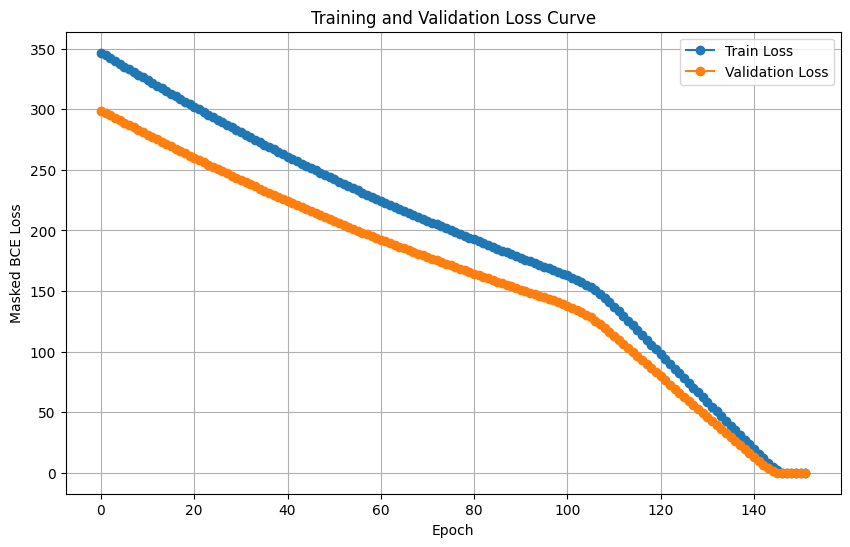

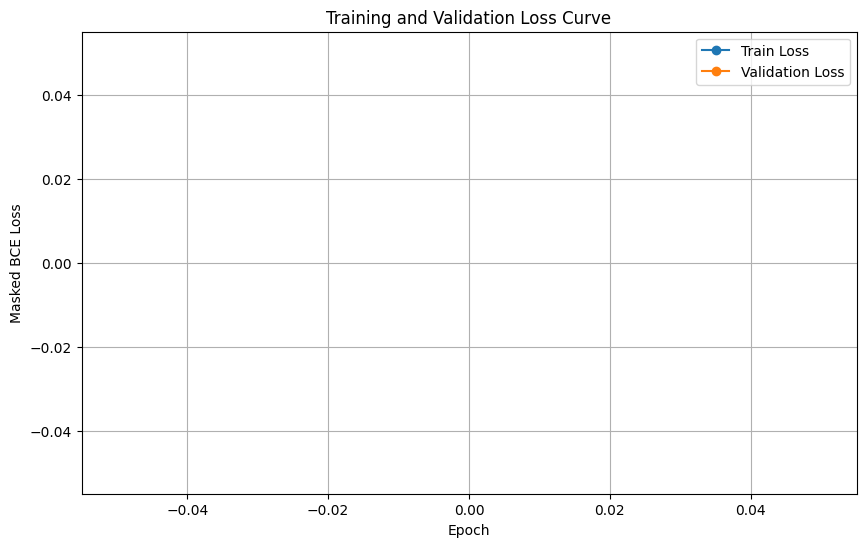

In [6]:
    
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_simple = GAT_simple(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

config = {
    'lr': 1e-3,
    'epochs': 200,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'GAT_simple_run'
}

         
  

trainer_simple = ImitationTrainer(
    model=model_simple,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)
print("\nStarting Training...")
trainer_simple.train()
trainer_simple.plot_losses()